##### 실행 환경 설정

In [1]:
# Google Drive를 Colab에 마운트
from google.colab import drive
drive.mount("/google_drive")

from pathlib import Path
from urllib.request import urlretrieve
import zipfile

# 작업 경로 설정
WORK_DIR = Path("/google_drive/Othercomputers/내 Mac/sec08")
if not WORK_DIR.exists():
    raise FileNotFoundError(f"작업 폴더를 찾을 수 없습니다: {WORK_DIR}")

print("\n[작업 폴더 목록]")
%cd {WORK_DIR}
!ls

# Colab 로컬 데이터셋 경로 설정
DATASET_ROOT = Path("/datasets")
DATASET_PATH = DATASET_ROOT / "coco128-seg"
DATASET_ZIP = DATASET_ROOT / "coco128-seg.zip"
DATASET_URL = (
    "https://github.com/ultralytics/assets/"
    "releases/download/v0.0.0/coco128-seg.zip"
)

DATASET_READY = all(
    (DATASET_PATH / relative_path).exists()
    for relative_path in ["images/train2017", "labels/train2017"]
)

if not DATASET_READY:
    DATASET_ROOT.mkdir(parents=True, exist_ok=True)
    print("\nCOCO128-seg 데이터셋 다운로드 중...")
    urlretrieve(DATASET_URL, DATASET_ZIP)

    print("COCO128-seg 데이터셋 압축 해제 중...")
    with zipfile.ZipFile(DATASET_ZIP, "r") as zip_file:
        zip_file.extractall(DATASET_ROOT)

    DATASET_ZIP.unlink(missing_ok=True)

print("\n[데이터셋 폴더 목록]")
print(DATASET_PATH)
!ls {DATASET_PATH}
print(DATASET_PATH / "images")
!ls {DATASET_PATH}/images
print(DATASET_PATH / "labels")
!ls {DATASET_PATH}/labels

# 한글 폰트 설치
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
!apt-get -qq install fonts-nanum
fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

Mounted at /google_drive

[작업 폴더 목록]
/google_drive/Othercomputers/내 Mac/sec08
01_object_detection_yolo_info.ipynb	      datasets
02_object_detection_yolo_dataset.ipynb	      detect
03_object_detection_yolo_train.ipynb	      runs
04_object_detection_yolo_visualization.ipynb  yolo11n.pt
05_segmentation_yolo_info.ipynb		      yolo11n-seg.pt
06_segmentation_yolo_train.ipynb	      yolo26n.pt
07_segmentation_yolo_visualization.ipynb      yolo26n-seg.pt

COCO128-seg 데이터셋 다운로드 중...
COCO128-seg 데이터셋 압축 해제 중...

[데이터셋 폴더 목록]
/datasets/coco128-seg
images	labels	LICENSE  README.txt
/datasets/coco128-seg/images
train2017
/datasets/coco128-seg/labels
train2017
Selecting previously unselected package fonts-nanum.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


##### 임포트

In [2]:
%pip install -q -U ultralytics

from ultralytics import YOLO
import torch
from pathlib import Path
from IPython.display import Image, display

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


##### YOLO 세그멘테이션 모델 구조

In [3]:
# 사전 학습된 YOLO 세그멘테이션 모델 로드 (없으면 자동 다운로드)
model = YOLO("yolo26n-seg.pt")

# 모델 구조 요약
model.info()
# Ultralytics 버전에 따라 레이어·파라미터·GFLOPs 수치는 달라질 수 있음
#   - layers    : 모델을 구성하는 총 레이어 수
#   - parameters: 학습 가능한 가중치의 총 개수
#   - gradients : 현재 역전파에 사용 중인 그래디언트 수 (추론 모드에서는 0)
#   - GFLOPs    : 이미지 1장 추론 시 필요한 연산량
# 반환값: (layers, parameters, gradients, GFLOPs) 튜플


YOLO26n-seg summary: 309 layers, 3,126,280 parameters, 0 gradients, 10.5 GFLOPs


(309, 3126280, 0, 10.509952)

##### 사전 학습된 COCO 80개 클래스

In [4]:
# 모델이 인식 가능한 클래스 목록 (COCO 80개 클래스)
print(f"클래스 수: {len(model.names)}")
print()
for idx, name in model.names.items():
    print(f"  {idx:2d}: {name}")

클래스 수: 80

   0: person
   1: bicycle
   2: car
   3: motorcycle
   4: airplane
   5: bus
   6: train
   7: truck
   8: boat
   9: traffic light
  10: fire hydrant
  11: stop sign
  12: parking meter
  13: bench
  14: bird
  15: cat
  16: dog
  17: horse
  18: sheep
  19: cow
  20: elephant
  21: bear
  22: zebra
  23: giraffe
  24: backpack
  25: umbrella
  26: handbag
  27: tie
  28: suitcase
  29: frisbee
  30: skis
  31: snowboard
  32: sports ball
  33: kite
  34: baseball bat
  35: baseball glove
  36: skateboard
  37: surfboard
  38: tennis racket
  39: bottle
  40: wine glass
  41: cup
  42: fork
  43: knife
  44: spoon
  45: bowl
  46: banana
  47: apple
  48: sandwich
  49: orange
  50: broccoli
  51: carrot
  52: hot dog
  53: pizza
  54: donut
  55: cake
  56: chair
  57: couch
  58: potted plant
  59: bed
  60: dining table
  61: toilet
  62: tv
  63: laptop
  64: mouse
  65: remote
  66: keyboard
  67: cell phone
  68: microwave
  69: oven
  70: toaster
  71: sink
  72: r

##### 추론해보기

사용 디바이스: cuda:0
Results saved to /google_drive/Othercomputers/내 Mac/sec08/runs/segment/05
/google_drive/Othercomputers/내 Mac/sec08/runs/segment/05/000000000532.jpg


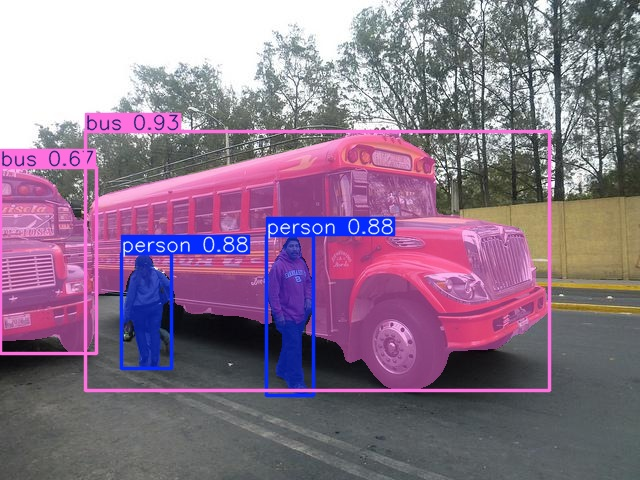

In [5]:
# 샘플 이미지와 추론 결과 저장 경로
image_path = DATASET_PATH / "images" / "train2017" / "000000000532.jpg"
if not image_path.exists():
    raise FileNotFoundError(f"샘플 이미지를 찾을 수 없습니다: {image_path}")

DEVICE = 0 if torch.cuda.is_available() else "cpu"
print("사용 디바이스:", "cuda:0" if DEVICE == 0 else DEVICE)

SEGMENT_PROJECT = Path(WORK_DIR) / "runs" / "segment"

# 추론 (verbose=False → 추론 로그 출력 숨김)
results = model(
    str(image_path),
    device=DEVICE,
    save=True,
    project=str(SEGMENT_PROJECT),
    name="05",
    exist_ok=True,
    verbose=False,
)

# 결과 이미지 출력
result_image_path = SEGMENT_PROJECT / "05" / image_path.name
print(result_image_path)
display(Image(filename=str(result_image_path)))